Loading Cat Images...
Loading Dog Images...

Dataset Shape: (1999, 1024)

Training SVM...

Accuracy: 0.595

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.59      0.59       200
           1       0.59      0.60      0.60       200

    accuracy                           0.59       400
   macro avg       0.60      0.59      0.59       400
weighted avg       0.60      0.59      0.59       400



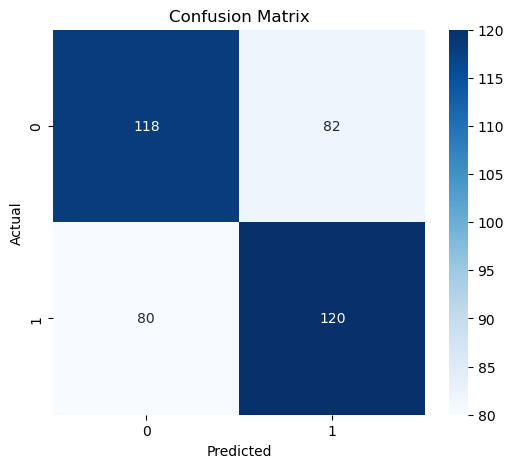

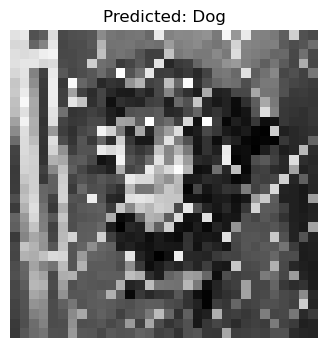

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = []
labels = []

cat_path = "PetImages/Cat"
dog_path = "PetImages/Dog"

print("Loading Cat Images...")

for img in os.listdir(cat_path)[:1000]:
    try:
        path = os.path.join(cat_path, img)
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            continue

        image = cv2.resize(image, (32, 32))
        data.append(image.flatten())
        labels.append(0)

    except:
        pass

print("Loading Dog Images...")

for img in os.listdir(dog_path)[:1000]:
    try:
        path = os.path.join(dog_path, img)
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            continue

        image = cv2.resize(image, (32, 32))
        data.append(image.flatten())
        labels.append(1)

    except:
        pass

X = np.array(data)
y = np.array(labels)

print("\nDataset Shape:", X.shape)

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining SVM...")

model = SVC(
    kernel='rbf',
    gamma='scale'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

sample = np.random.randint(0, len(X_test))

image = X_test[sample].reshape(32,32)

plt.figure(figsize=(4,4))
plt.imshow(image, cmap='gray')

pred = model.predict([X_test[sample]])[0]

if pred == 0:
    plt.title("Predicted: Cat")
else:
    plt.title("Predicted: Dog")

plt.axis("off")
plt.show()